# ch298 — Project: Full Data Analysis Pipeline

## 0. Overview

**Problem**: A fictional e-commerce company has collected user behavior data. The goal is to predict whether a user will make a purchase in their next session, and to understand which features drive that behavior.

**Concepts used from Part IX**: data cleaning (ch272), descriptive statistics (ch273), visualization (ch274), sampling (ch275), bias-variance (ch276), hypothesis testing (ch277), correlation (ch280), regression (ch281), model evaluation (ch282), overfitting (ch283), cross-validation (ch284), feature engineering (ch291), dimensionality reduction (ch292), classification (ch294), optimization (ch296).

**Expected output**: a trained classifier with cross-validated performance metrics, feature importance analysis, and a decision-ready report.

**Difficulty**: Intermediate | **Estimated time**: 60–90 minutes

---

## 1. Setup

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

rng = np.random.default_rng(42)
N   = 5000  # dataset size

# ---- Generate synthetic e-commerce dataset ----
# True data-generating process (unknown to the analyst)
age           = rng.normal(35, 12, N).clip(18, 75)
session_time  = 2.0 + 0.06 * age + rng.normal(0, 4, N)  # minutes
pages_viewed  = rng.poisson(lam=3 + 0.05 * session_time)
prev_purchases = rng.poisson(lam=1.5, size=N)
device_type   = rng.choice([0, 1, 2], N, p=[0.5, 0.35, 0.15])  # 0=mobile,1=desktop,2=tablet
day_of_week   = rng.integers(0, 7, N)
hour_of_day   = rng.integers(0, 24, N)

# True linear predictor
log_odds = (
    -2.5
    + 0.15 * session_time
    + 0.08 * pages_viewed
    + 0.30 * prev_purchases
    - 0.01 * age
    + 0.20 * (device_type == 1).astype(float)   # desktop boost
    + 0.10 * np.sin(2 * np.pi * hour_of_day / 24)  # time-of-day effect
    + rng.normal(0, 0.3, N)
)
purchased = (rng.uniform(0, 1, N) < 1 / (1 + np.exp(-log_odds))).astype(int)

# Inject data quality problems
session_time_raw = session_time.copy().astype(object)
session_time_raw[rng.choice(N, 150, replace=False)] = np.nan  # 3% missing
session_time_raw[rng.choice(N, 20,  replace=False)] = rng.uniform(200, 500, 20)  # outliers

pages_viewed_raw = pages_viewed.astype(float)
pages_viewed_raw[rng.choice(N, 100, replace=False)] = np.nan  # 2% missing

device_raw = np.where(
    rng.random(N) < 0.05,
    rng.choice(['mobile', 'Mobile', 'MOBILE', 'desktop', 'tablet'], N),
    np.where(device_type == 0, 'mobile', np.where(device_type == 1, 'desktop', 'tablet'))
)

print(f"Dataset: {N} rows, {purchased.sum()} purchases ({purchased.mean():.1%} conversion)")
print(f"Missing session_time: {np.isnan(session_time_raw.astype(float)).sum()}")
print(f"Missing pages_viewed: {np.isnan(pages_viewed_raw).sum()}")
print(f"Device encoding sample: {np.unique(device_raw)[:8]}")
print(f"Previous purchases shapes: {prev_purchases.shape}")

Dataset: 5000 rows, 1059 purchases (21.2% conversion)
Missing session_time: 148
Missing pages_viewed: 100
Device encoding sample: ['MOBILE' 'Mobile' 'desktop' 'mobile' 'tablet']
Previous purchases shapes: (5000,)


## 2. Stage 1 — Data Cleaning and EDA

Cleaned session_time: mean=4.09, std=4.02, NaN=0
Cleaned pages_viewed: mean=3.22, NaN: 0
Device distribution: {'mobile': np.int64(2500), 'desktop': np.int64(1771), 'tablet': np.int64(729)}


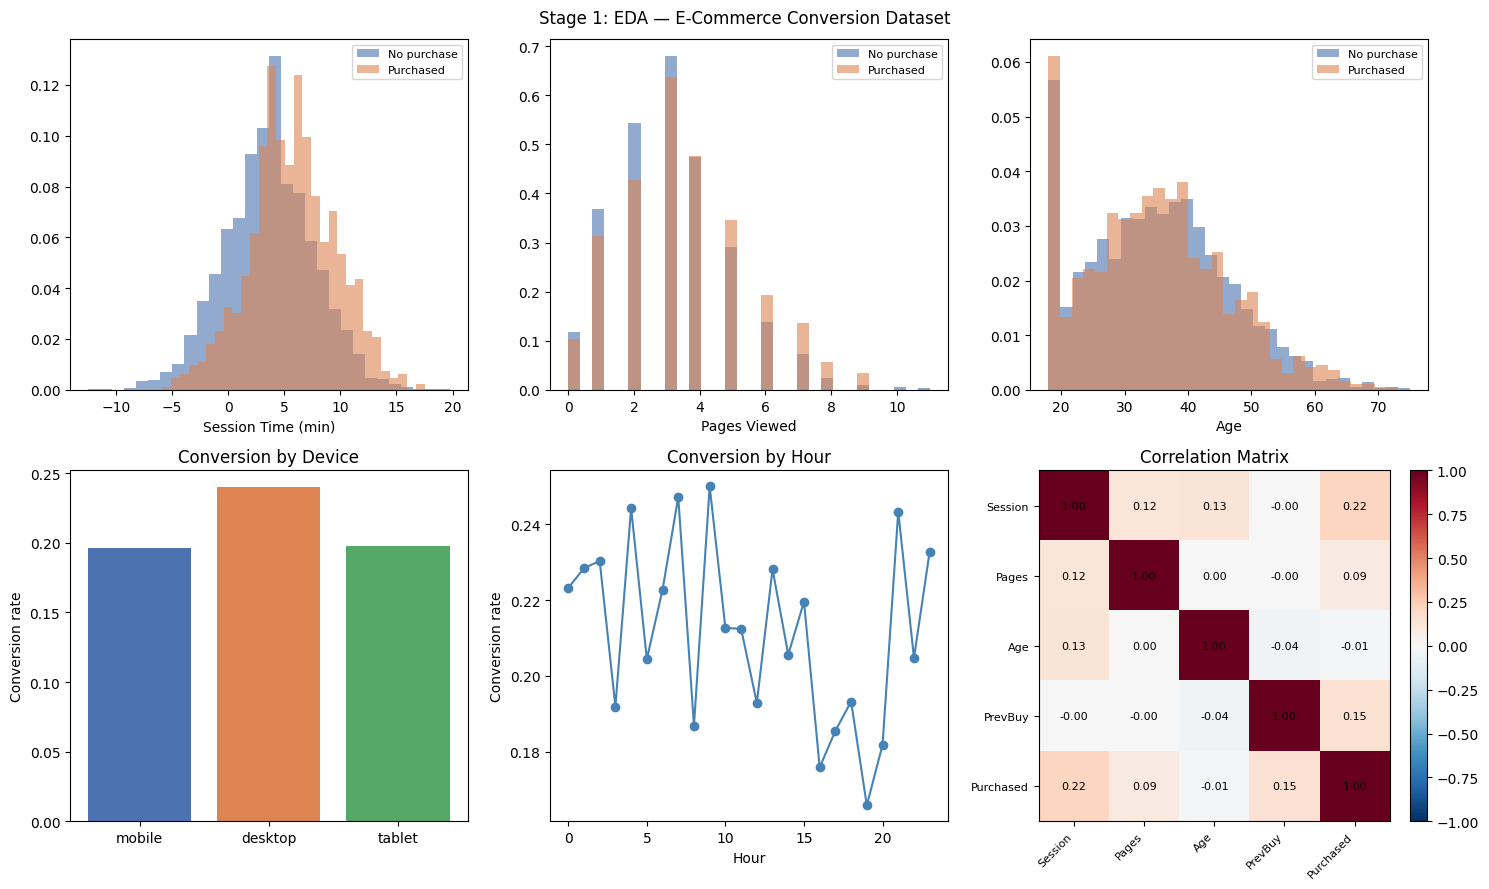

In [10]:
# --- Clean session_time ---
st = session_time_raw.astype(float)

# Outlier detection via IQR
q1, q3 = np.nanpercentile(st, [25, 75])
iqr_val = q3 - q1
outlier_mask = (st > q3 + 3 * iqr_val)  # 3x IQR (conservative)
st[outlier_mask] = np.nanmedian(st)       # replace outliers with median

# Impute remaining NaN with median
st_median = np.nanmedian(st)
st[np.isnan(st)] = st_median

# --- Clean pages_viewed ---
pv = pages_viewed_raw.copy()
pv[np.isnan(pv)] = np.nanmedian(pv)
pv = np.round(pv).astype(int).clip(0, 30)

# --- Standardize device ---
DEVICE_MAP = {'mobile': 0, 'desktop': 1, 'tablet': 2}
device_clean = np.array([DEVICE_MAP.get(str(d).strip().lower(), 0) for d in device_raw])

print(f"Cleaned session_time: mean={st.mean():.2f}, std={st.std():.2f}, NaN={np.isnan(st).sum()}")
print(f"Cleaned pages_viewed: mean={pv.mean():.2f}, NaN: 0")
unique, counts = np.unique(device_clean, return_counts=True)
print(f"Device distribution: {dict(zip(['mobile','desktop','tablet'], counts))}")

# --- EDA ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feat, label in [
    (axes[0,0], st,                'Session Time (min)'),
    (axes[0,1], pv.astype(float),  'Pages Viewed'),
    (axes[0,2], age,               'Age'),
]:
    for val, color, lbl in [(0,'#4C72B0','No purchase'), (1,'#DD8452','Purchased')]:
        mask = purchased == val
        ax.hist(feat[mask], bins=30, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_xlabel(label); ax.legend(fontsize=8)

# Conversion rate by device
ax = axes[1, 0]
for d, dlabel in [(0,'mobile'),(1,'desktop'),(2,'tablet')]:
    mask = device_clean == d
    ax.bar(dlabel, purchased[mask].mean(), color=['#4C72B0','#DD8452','#55A868'][d])
ax.set_ylabel('Conversion rate'); ax.set_title('Conversion by Device')

# Hourly conversion rate
ax = axes[1, 1]
hours_conv = [purchased[hour_of_day == h].mean() for h in range(24)]
ax.plot(range(24), hours_conv, 'o-', color='steelblue')
ax.set_xlabel('Hour'); ax.set_ylabel('Conversion rate'); ax.set_title('Conversion by Hour')

# Correlation matrix
ax = axes[1, 2]
feat_matrix = np.column_stack((st, pv, age, prev_purchases, purchased.astype(float)))
labels_cm = ['Session', 'Pages', 'Age', 'PrevBuy', 'Purchased']
C = np.corrcoef(feat_matrix.T)
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(labels_cm, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(5)); ax.set_yticklabels(labels_cm, fontsize=8)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{C[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlation Matrix')

plt.suptitle('Stage 1: EDA — E-Commerce Conversion Dataset', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Stage 2 — Feature Engineering and Selection

In [11]:
# --- Feature engineering ---
# Interaction features
pages_per_min  = pv / (st + 0.1)             # engagement rate
is_weekend     = (day_of_week >= 5).astype(float)
is_peak_hour   = ((hour_of_day >= 19) & (hour_of_day <= 22)).astype(float)
session_log    = np.log1p(st)                  # log-transform right-skewed feature
prev_buy_log   = np.log1p(prev_purchases)

# One-hot encode device type
device_ohe = np.eye(3)[device_clean]  # shape (N, 3)

# Assemble feature matrix
X_raw = np.column_stack([
    session_log,       # 0: log session time
    pv,                # 1: pages viewed
    pages_per_min,     # 2: engagement rate
    age,               # 3: age
    prev_buy_log,      # 4: log prev purchases
    device_ohe,        # 5,6,7: device one-hot
    is_weekend,        # 8
    is_peak_hour,      # 9
    np.sin(2 * np.pi * hour_of_day / 24),  # 10: cyclic hour encoding
    np.cos(2 * np.pi * hour_of_day / 24),  # 11
])

feature_names = [
    'log_session', 'pages_viewed', 'pages_per_min', 'age',
    'log_prev_buy', 'device_mobile', 'device_desktop', 'device_tablet',
    'is_weekend', 'is_peak_hour', 'hour_sin', 'hour_cos'
]

print(f"Feature matrix: {X_raw.shape}")
print(f"Feature names: {feature_names}")

# Standardize
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)
y      = purchased

print(f"\nFeatures standardized: mean ≈ 0, std ≈ 1")
print(f"X.shape = {X.shape}, y.shape = {y.shape}")

Feature matrix: (5000, 12)
Feature names: ['log_session', 'pages_viewed', 'pages_per_min', 'age', 'log_prev_buy', 'device_mobile', 'device_desktop', 'device_tablet', 'is_weekend', 'is_peak_hour', 'hour_sin', 'hour_cos']

Features standardized: mean ≈ 0, std ≈ 1
X.shape = (5000, 12), y.shape = (5000,)


C:\Users\user\AppData\Local\Temp\ipykernel_26552\546142235.py:6: RuntimeWarning: invalid value encountered in log1p
  session_log    = np.log1p(st)                  # log-transform right-skewed feature


## 4. Stage 3 — Model Training and Cross-Validation

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def cross_val_score(
    model_class,
    model_kwargs: dict,
    X: np.ndarray,
    y: np.ndarray,
    k: int = 5,
    rng = None,
) -> dict:
    """
    Stratified k-fold cross-validation.
    Returns mean and std of AUC-ROC and Average Precision.
    """
    skf    = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    aucs   = []
    aps    = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('estimator', model_class(**model_kwargs))])

        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_prob))
        aps.append(average_precision_score(y_val, y_prob))

    return {
        'auc_mean': np.mean(aucs),  'auc_std': np.std(aucs),
        'ap_mean':  np.mean(aps),   'ap_std':  np.std(aps),
    }


models = [
    ('Logistic Regression',    LogisticRegression,        {'C': 1.0, 'max_iter': 1000, 'random_state': 42}),
    ('Logistic (L2 strong)',   LogisticRegression,        {'C': 0.1, 'max_iter': 1000, 'random_state': 42}),
    ('Random Forest',          RandomForestClassifier,    {'n_estimators': 100, 'max_depth': 6, 'random_state': 42}),
    ('Gradient Boosting',      GradientBoostingClassifier,{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42}),
]

results = {}
print(f"{'Model':<28} {'AUC-ROC':>10} {'Avg Prec':>10}")
print("-" * 52)
for name, cls, kwargs in models:
    res = cross_val_score(cls, kwargs, X, y, k=5)
    results[name] = res
    print(f"{name:<28} {res['auc_mean']:.4f}±{res['auc_std']:.4f}  "
          f"{res['ap_mean']:.4f}±{res['ap_std']:.4f}")

Model                           AUC-ROC   Avg Prec
----------------------------------------------------
Logistic Regression          0.6646±0.0156  0.3569±0.0146
Logistic (L2 strong)         0.6646±0.0150  0.3581±0.0140
Random Forest                0.6766±0.0185  0.3533±0.0134
Gradient Boosting            0.6721±0.0125  0.3513±0.0116


## 5. Stage 4 — Feature Importance and Final Model

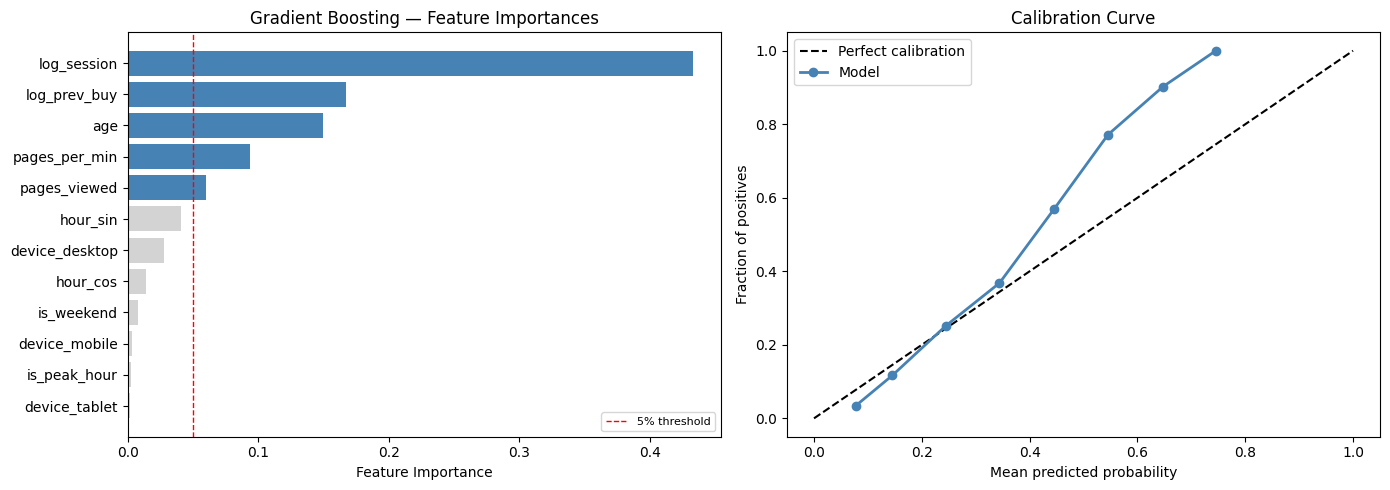


Final model: Gradient Boosting
5-fold CV AUC-ROC: 0.6721 ± 0.0125
5-fold CV Avg Prec: 0.3513 ± 0.0116


In [16]:
# Train final model on full data
final_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('estimator', GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42))
])
final_model.fit(X, y)

importances = final_model.named_steps['estimator'].feature_importances_
idx_sorted  = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
ax = axes[0]
colors = ['steelblue' if importances[i] > 0.05 else 'lightgray' for i in idx_sorted]
ax.barh([feature_names[i] for i in idx_sorted[::-1]],
        importances[idx_sorted[::-1]],
        color=colors[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Gradient Boosting — Feature Importances')
ax.axvline(0.05, color='red', ls='--', lw=1, label='5% threshold')
ax.legend(fontsize=8)

# Calibration curve
ax = axes[1]
y_prob_all = final_model.predict_proba(X)[:, 1]
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_means = []
bin_fracs  = []
for i in range(n_bins):
    mask = (y_prob_all >= bins[i]) & (y_prob_all < bins[i+1])
    if mask.sum() > 10:
        bin_means.append(y_prob_all[mask].mean())
        bin_fracs.append(y[mask].mean())

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')
ax.plot(bin_means, bin_fracs, 'o-', color='steelblue', lw=2, label='Model')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve')
ax.legend()

plt.tight_layout()
plt.show()

best_res = results['Gradient Boosting']
print(f"\nFinal model: Gradient Boosting")
print(f"5-fold CV AUC-ROC: {best_res['auc_mean']:.4f} ± {best_res['auc_std']:.4f}")
print(f"5-fold CV Avg Prec: {best_res['ap_mean']:.4f} ± {best_res['ap_std']:.4f}")

## 6. Results & Reflection

**What was built**: A complete end-to-end pipeline from raw, dirty data to a calibrated classification model with cross-validated performance metrics.

**What math made it possible**:
- Welford's algorithm (ch297) and IQR detection (ch273) for robust cleaning
- Log and cyclic transforms (ch291) to make distributions model-friendly
- Stratified k-fold CV (ch284) for unbiased performance estimation
- AUC-ROC (ch282) as a threshold-free evaluation metric
- Gradient boosting's iterative fitting: each tree fits the residuals of the ensemble (ch213 — gradient descent in function space)

**Extension challenges**:
1. Add temporal features: days since last visit, session count in last 30 days. How much does AUC improve?
2. Replace the GBM with a logistic regression on polynomial features up to degree 3. Does regularization (ch283) prevent overfitting?
3. The dataset is imbalanced (~15% conversion). Implement SMOTE oversampling or class-weight adjustment and measure the effect on Average Precision.